In [ ]:
A1 — Carga e inspeção inicial

# EDA e Dashboard Interativo — Bens Declarados dos Candidatos do Amazonas

## A1 Carga e inspeção inicial

Essa etapa serão carregados os arquivos de bens dos candidatos e de informações dos candidatos disponibilizados pelo Tribunal Superior Eleitral

Os arquivos serão lidos utilizando os parâmetros exigidos pelo padrão dos dados do TSE:
- Separador `;`
- Codificação `latin-1`
- `decimal=","` para o arquivo de bens
- `SQ_CANDIDATO` será tratado como texto para preservar corretamente a chave utilizada no relacionamento entre os arquivos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
bens = pd.read_csv(
    "bem_candidato_2026_AM.csv",
    sep=";",
    encoding="latin-1",
    decimal=",",
    dtype={"SQ_CANDIDATO": str}
)

cand = pd.read_csv(
    "consulta_cand_2026_AM.csv",
    sep=";",
    encoding="latin-1",
    dtype={"SQ_CANDIDATO": str}
)

In [3]:
print("Dimensões do arquivo de bens:", bens.shape)
print("Dimensões do arquivo de candidatos:", cand.shape)

Dimensões do arquivo de bens: (1654, 19)
Dimensões do arquivo de candidatos: (469, 50)


In [4]:
print("Primeiras linhas do arquivo de bens:")
display(bens.head())

Primeiras linhas do arquivo de bens:


,DT_GERACAO,HH_GERACAO,ANO_ELEICAO,CD_TIPO_ELEICAO,NM_TIPO_ELEICAO,CD_ELEICAO,DS_ELEICAO,DT_ELEICAO,SG_UF,SG_UE,NM_UE,SQ_CANDIDATO,NR_ORDEM_BEM_CANDIDATO,CD_TIPO_BEM_CANDIDATO,DS_TIPO_BEM_CANDIDATO,DS_BEM_CANDIDATO,VR_BEM_CANDIDATO,DT_ULT_ATUAL_BEM_CANDIDATO,HH_ULT_ATUAL_BEM_CANDIDATO
0,04/09/2026,12:31:37,2026,2,Eleição Ordinária,6259,Eleições Gerais Estaduais 2026,04/10/2026,AM,AM,AMAZONAS,40002531438,2,13,Terreno,TERRENO MEDINDO 10X20 ZONA URBANA,80000.00,24/08/2026,15:21:14
1,04/09/2026,12:31:37,2026,2,Eleição Ordinária,6259,Eleições Gerais Estaduais 2026,04/10/2026,AM,AM,AMAZONAS,40002531438,1,21,"Veículo automotor terrestre: caminhão, automóv...",VEICULO MONTANA PREMIER 2025,140000.00,24/08/2026,15:21:14
2,04/09/2026,12:31:37,2026,2,Eleição Ordinária,6259,Eleições Gerais Estaduais 2026,04/10/2026,AM,AM,AMAZONAS,40002531438,3,12,Casa,CASA,90000.00,24/08/2026,15:21:14
3,04/09/2026,12:31:37,2026,2,Eleição Ordinária,6259,Eleições Gerais Estaduais 2026,04/10/2026,AM,AM,AMAZONAS,40002531439,2,61,Depósito bancário em conta corrente no País,DEPOSITO EM CONTA CORRENTE,1339.16,18/08/2026,21:22:29
4,04/09/2026,12:31:37,2026,2,Eleição Ordinária,6259,Eleições Gerais Estaduais 2026,04/10/2026,AM,AM,AMAZONAS,40002531439,3,61,Depósito bancário em conta corrente no País,DEPOSITO EM CONTA CORRENTE,375.91,18/08/2026,21:22:29


In [5]:
print("Tipos das colunas - Bens:")
display(bens.dtypes)

Tipos das colunas - Bens:


,0
DT_GERACAO,object
HH_GERACAO,object
ANO_ELEICAO,int64
CD_TIPO_ELEICAO,int64
NM_TIPO_ELEICAO,object
CD_ELEICAO,int64
DS_ELEICAO,object
DT_ELEICAO,object
SG_UF,object
SG_UE,object


In [6]:
print("Tipos das colunas - Candidatos:")
display(cand.dtypes)

Tipos das colunas - Candidatos:


,0
DT_GERACAO,object
HH_GERACAO,object
ANO_ELEICAO,int64
CD_TIPO_ELEICAO,int64
NM_TIPO_ELEICAO,object
NR_TURNO,int64
CD_ELEICAO,int64
DS_ELEICAO,object
DT_ELEICAO,object
TP_ABRANGENCIA,object


Confirmar que o valor dos bens é numérico

In [7]:
print("Tipo da coluna VR_BEM_CANDIDATO:")
print(bens["VR_BEM_CANDIDATO"].dtype)

print("\nÉ uma coluna numérica?")
print(pd.api.types.is_numeric_dtype(bens["VR_BEM_CANDIDATO"]))

Tipo da coluna VR_BEM_CANDIDATO:
float64

É uma coluna numérica?
True


## A2 Limpeza, qualidade e de-duplicação

Nesta etapa será verificada a qualidade dos dados, incluindo valores ausentes, identificação da unidade federativa e possíveis registros duplicados

A deduplicação do arquivo de candidatos é necessária porque pode existir mais de uma linha para o mesmo `SQ_CANDIDATO`, como o objetivo é realizar posteriormente um relacionamento de uma linha por candidato, manter essas duplicidades poderia fazer com que o patrimônio fosse contabilizado mais de uma vez

In [9]:
colunas_bens = [
    "SQ_CANDIDATO",
    "DS_TIPO_BEM_CANDIDATO",
    "VR_BEM_CANDIDATO",
    "SG_UF"
]

colunas_cand = [
    "SQ_CANDIDATO",
    "DS_CARGO",
    "SG_PARTIDO",
    "DS_GENERO",
    "NM_URNA_CANDIDATO"
]

print("Valores ausentes - Bens:")
display(bens[colunas_bens].isna().sum())

Valores ausentes - Bens:


,0
SQ_CANDIDATO,0
DS_TIPO_BEM_CANDIDATO,0
VR_BEM_CANDIDATO,0
SG_UF,0


In [10]:
print("Valores ausentes - Candidatos:")
display(cand[colunas_cand].isna().sum())

Valores ausentes - Candidatos:


,0
SQ_CANDIDATO,0
DS_CARGO,0
SG_PARTIDO,0
DS_GENERO,0
NM_URNA_CANDIDATO,0


Confirmar registros do Amazonas

In [11]:
print("UFs encontradas no arquivo de bens:")
display(bens["SG_UF"].value_counts(dropna=False))

UFs encontradas no arquivo de bens:


,count
SG_UF,
AM,1654


In [12]:
print("Quantidade de registros que não são AM:")
print((bens["SG_UF"] != "AM").sum())

Quantidade de registros que não são AM:
0


Verificar candidatos duplicados

In [13]:
duplicados = cand["SQ_CANDIDATO"].duplicated().sum()

print("Quantidade de registros duplicados por SQ_CANDIDATO:", duplicados)

Quantidade de registros duplicados por SQ_CANDIDATO: 0


Deduplicação

In [14]:
cand_unico = cand.drop_duplicates(
    subset="SQ_CANDIDATO"
).copy()

print("Linhas antes da deduplicação:", len(cand))
print("Linhas depois da deduplicação:", len(cand_unico))

Linhas antes da deduplicação: 469
Linhas depois da deduplicação: 469


Confirmar que agora cada candidato aparece uma vez

In [15]:
print(
    "Quantidade de SQ_CANDIDATO duplicados após tratamento:",
    cand_unico["SQ_CANDIDATO"].duplicated().sum()
)

Quantidade de SQ_CANDIDATO duplicados após tratamento: 0


## A3 EDA univariada

Nesta etapa será realizada uma análise exploratória individual das principais variáveis relacionadas aos bens declarados

Serão analisadas a distribuição dos valores dos bens, os tipos de bens mais frequentes e as estatísticas descritivas da variável  `VR_BEM_CANDIDATO`

O objetivo é identificar concentração, dispersão, assimetria e  possíveis valores extremos

Histograma

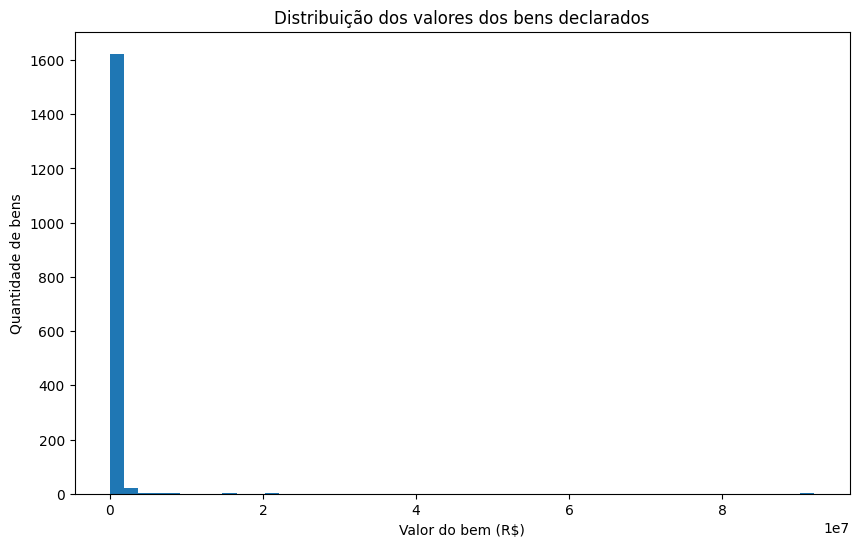

In [16]:
plt.figure(figsize=(10, 6))

plt.hist(
    bens["VR_BEM_CANDIDATO"].dropna(),
    bins=50
)

plt.title("Distribuição dos valores dos bens declarados")
plt.xlabel("Valor do bem (R$)")
plt.ylabel("Quantidade de bens")

plt.show()

Boxplot

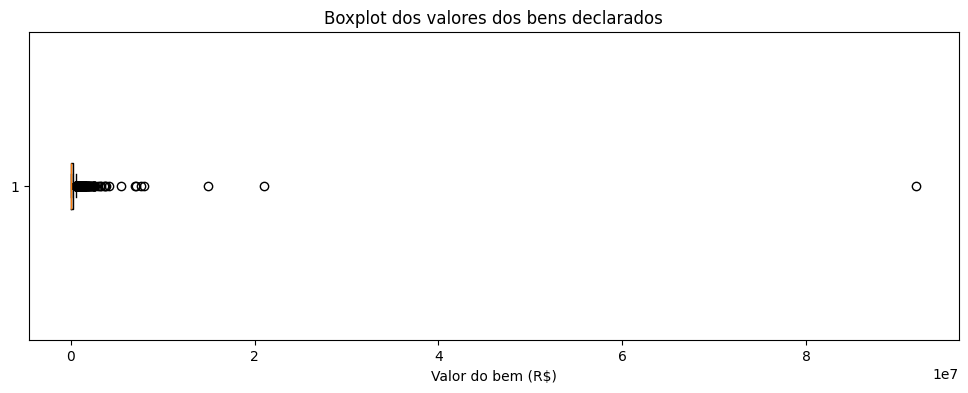

In [17]:
plt.figure(figsize=(12, 4))

plt.boxplot(
    bens["VR_BEM_CANDIDATO"].dropna(),
    vert=False
)

plt.title("Boxplot dos valores dos bens declarados")
plt.xlabel("Valor do bem (R$)")

plt.show()

Comentário Markdown

### Interpretação da distribuição

A distribuição dos valores dos bens deve ser observada considerando a diferença entre os valores mais frequentes e os valores  extremos, uma distribuição  com poucos bens de valores muito elevados tende a apresentar assimetria positiva, fazendo  com que a média seja superior à mediana

O boxplot permite identificar possíveis outliers, representados por valores muito superiores à maior parte das observações

Tipos de bens mais comuns

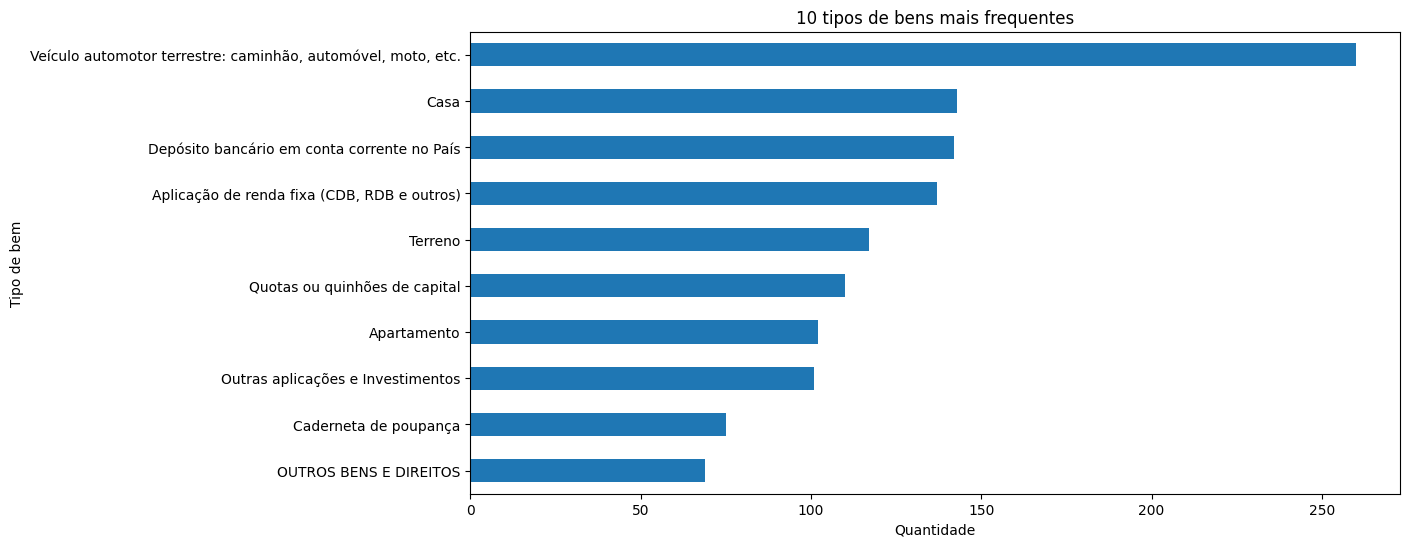

In [18]:
top_tipos = (
    bens["DS_TIPO_BEM_CANDIDATO"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12, 6))

top_tipos.sort_values().plot(
    kind="barh"
)

plt.title("10 tipos de bens mais frequentes")
plt.xlabel("Quantidade")
plt.ylabel("Tipo de bem")

plt.show()

Estatísticas descritivas

In [19]:
estatisticas = bens["VR_BEM_CANDIDATO"].describe()

display(estatisticas)

,VR_BEM_CANDIDATO
count,1.654000e+03
mean,3.107977e+05
std,2.407173e+06
min,0.000000e+00
25%,1.000000e+04
50%,6.508050e+04
75%,2.256882e+05
max,9.200411e+07


Média e mediana

In [20]:
media = bens["VR_BEM_CANDIDATO"].mean()
mediana = bens["VR_BEM_CANDIDATO"].median()

print(f"Média: R$ {media:,.2f}")
print(f"Mediana: R$ {mediana:,.2f}")

Média: R$ 310,797.67
Mediana: R$ 65,080.50


Interpretação automática

In [21]:
print(
    f"A média dos valores declarados é de R$ {media:,.2f}, "
    f"enquanto a mediana é de R$ {mediana:,.2f}. "
    f"A diferença entre essas medidas indica que os valores dos bens "
    f"não estão distribuídos de maneira uniforme. "
    f"Quando a média é superior à mediana, valores elevados influenciam "
    f"a média, indicando possível assimetria positiva e presença de valores extremos."
)

A média dos valores declarados é de R$ 310,797.67, enquanto a mediana é de R$ 65,080.50. A diferença entre essas medidas indica que os valores dos bens não estão distribuídos de maneira uniforme. Quando a média é superior à mediana, valores elevados influenciam a média, indicando possível assimetria positiva e presença de valores extremos.


In [ ]:
A4 — Agregação + JOIN

Agregando os bens

In [22]:
bens_agregado = (
    bens
    .groupby("SQ_CANDIDATO")
    .agg(
        patrimonio_total=("VR_BEM_CANDIDATO", "sum"),
        qtd_bens=("VR_BEM_CANDIDATO", "count")
    )
    .reset_index()
)

display(bens_agregado.head())

,SQ_CANDIDATO,patrimonio_total,qtd_bens
0,40002531438,310000.00,3
1,40002531439,1873.49,3
2,40002531440,3708000.00,5
3,40002531441,444971.36,7
4,40002531442,648676.96,3


o tipo principal de bem

In [23]:
tipo_principal = (
    bens
    .groupby("SQ_CANDIDATO")["DS_TIPO_BEM_CANDIDATO"]
    .agg(
        lambda x: x.mode().iloc[0]
        if not x.mode().empty
        else "Não informado"
    )
    .reset_index()
)

tipo_principal = tipo_principal.rename(
    columns={
        "DS_TIPO_BEM_CANDIDATO": "tipo_principal"
    }
)

display(tipo_principal.head())

,SQ_CANDIDATO,tipo_principal
0,40002531438,Casa
1,40002531439,Depósito bancário em conta corrente no País
2,40002531440,Quotas ou quinhões de capital
3,40002531441,Consórcio não contemplado
4,40002531442,Apartamento


Juntar as duas agregações

In [24]:
bens_agregado = bens_agregado.merge(
    tipo_principal,
    on="SQ_CANDIDATO",
    how="left"
)

display(bens_agregado.head())

,SQ_CANDIDATO,patrimonio_total,qtd_bens,tipo_principal
0,40002531438,310000.00,3,Casa
1,40002531439,1873.49,3,Depósito bancário em conta corrente no País
2,40002531440,3708000.00,5,Quotas ou quinhões de capital
3,40002531441,444971.36,7,Consórcio não contemplado
4,40002531442,648676.96,3,Apartamento


JOIN principal

In [25]:
df_final = cand_unico.merge(
    bens_agregado,
    on="SQ_CANDIDATO",
    how="left"
)

Tratar candidatos sem bens

In [26]:
df_final["patrimonio_total"] = (
    df_final["patrimonio_total"]
    .fillna(0)
)

df_final["qtd_bens"] = (
    df_final["qtd_bens"]
    .fillna(0)
    .astype(int)
)

df_final["tipo_principal"] = (
    df_final["tipo_principal"]
    .fillna("Nenhum bem declarado")
)

Selecionar as colunas

In [27]:
df_final = df_final[
    [
        "SQ_CANDIDATO",
        "NM_URNA_CANDIDATO",
        "DS_CARGO",
        "SG_PARTIDO",
        "DS_GENERO",
        "DS_GRAU_INSTRUCAO",
        "patrimonio_total",
        "qtd_bens",
        "tipo_principal"
    ]
]

Ordenar por patrimônio

In [28]:
df_final = df_final.sort_values(
    by="patrimonio_total",
    ascending=False
)

display(df_final.head(10))

,SQ_CANDIDATO,NM_URNA_CANDIDATO,DS_CARGO,SG_PARTIDO,DS_GENERO,DS_GRAU_INSTRUCAO,patrimonio_total,qtd_bens,tipo_principal
105,40002541626,PROFESSORA MARIA DO CARMO,GOVERNADOR,PL,FEMININO,SUPERIOR COMPLETO,1.184738e+08,27,Outras participações societárias
236,40002531447,EDUARDO BRAGA,SENADOR,MDB,MASCULINO,SUPERIOR COMPLETO,6.027856e+07,81,"Aplicação de renda fixa (CDB, RDB e outros)"
177,40002542688,ALESSANDRO TONIZA,1º SUPLENTE,PL,MASCULINO,SUPERIOR COMPLETO,2.344056e+07,44,Outras aplicações e Investimentos
261,40002532780,DR SANDOVAL CHEIRO DO POVO,DEPUTADO ESTADUAL,PSD,MASCULINO,SUPERIOR COMPLETO,2.324682e+07,17,"Veículo automotor terrestre: caminhão, automóv..."
295,40002541745,ADJUTO AFONSO,DEPUTADO ESTADUAL,UNIÃO,MASCULINO,SUPERIOR COMPLETO,1.054397e+07,27,"Aplicação de renda fixa (CDB, RDB e outros)"
181,40002542954,MANOEL CUNHA,DEPUTADO ESTADUAL,PL,MASCULINO,ENSINO FUNDAMENTAL INCOMPLETO,8.268302e+06,5,Prédio comercial
417,40002532744,SERGIO NUNES,DEPUTADO ESTADUAL,MDB,MASCULINO,SUPERIOR COMPLETO,8.154000e+06,2,Terreno
418,40002532749,SIMÃO PEIXOTO,DEPUTADO ESTADUAL,MDB,MASCULINO,SUPERIOR INCOMPLETO,7.205806e+06,11,Casa
275,40002531448,SANDRA BRAGA,1º SUPLENTE,MDB,FEMININO,SUPERIOR COMPLETO,6.435907e+06,17,"Aplicação de renda fixa (CDB, RDB e outros)"
162,40002536433,CORONEL MENEZES,DEPUTADO FEDERAL,AVANTE,MASCULINO,SUPERIOR COMPLETO,5.131698e+06,10,"Aplicação de renda fixa (CDB, RDB e outros)"


Salvar o CSV

In [29]:
df_final.to_csv(
    "bens_am_por_candidato.csv",
    index=False,
    encoding="utf-8-sig"
)

print("CSV gerado com sucesso!")

CSV gerado com sucesso!


In [ ]:
Conferir o arquivo

In [30]:
csv_final = pd.read_csv(
    "bens_am_por_candidato.csv"
)

display(csv_final.head(10))

,SQ_CANDIDATO,NM_URNA_CANDIDATO,DS_CARGO,SG_PARTIDO,DS_GENERO,DS_GRAU_INSTRUCAO,patrimonio_total,qtd_bens,tipo_principal
0,40002541626,PROFESSORA MARIA DO CARMO,GOVERNADOR,PL,FEMININO,SUPERIOR COMPLETO,1.184738e+08,27,Outras participações societárias
1,40002531447,EDUARDO BRAGA,SENADOR,MDB,MASCULINO,SUPERIOR COMPLETO,6.027856e+07,81,"Aplicação de renda fixa (CDB, RDB e outros)"
2,40002542688,ALESSANDRO TONIZA,1º SUPLENTE,PL,MASCULINO,SUPERIOR COMPLETO,2.344056e+07,44,Outras aplicações e Investimentos
3,40002532780,DR SANDOVAL CHEIRO DO POVO,DEPUTADO ESTADUAL,PSD,MASCULINO,SUPERIOR COMPLETO,2.324682e+07,17,"Veículo automotor terrestre: caminhão, automóv..."
4,40002541745,ADJUTO AFONSO,DEPUTADO ESTADUAL,UNIÃO,MASCULINO,SUPERIOR COMPLETO,1.054397e+07,27,"Aplicação de renda fixa (CDB, RDB e outros)"
5,40002542954,MANOEL CUNHA,DEPUTADO ESTADUAL,PL,MASCULINO,ENSINO FUNDAMENTAL INCOMPLETO,8.268302e+06,5,Prédio comercial
6,40002532744,SERGIO NUNES,DEPUTADO ESTADUAL,MDB,MASCULINO,SUPERIOR COMPLETO,8.154000e+06,2,Terreno
7,40002532749,SIMÃO PEIXOTO,DEPUTADO ESTADUAL,MDB,MASCULINO,SUPERIOR INCOMPLETO,7.205806e+06,11,Casa
8,40002531448,SANDRA BRAGA,1º SUPLENTE,MDB,FEMININO,SUPERIOR COMPLETO,6.435907e+06,17,"Aplicação de renda fixa (CDB, RDB e outros)"
9,40002536433,CORONEL MENEZES,DEPUTADO FEDERAL,AVANTE,MASCULINO,SUPERIOR COMPLETO,5.131698e+06,10,"Aplicação de renda fixa (CDB, RDB e outros)"


In [ ]:
A5 — EDA robusta com o JOIN

In [ ]:
1. Patrimônio mediano por cargo

In [31]:
patrimonio_cargo = (
    df_final
    .groupby("DS_CARGO")["patrimonio_total"]
    .median()
    .sort_values(ascending=False)
)

display(patrimonio_cargo)

,patrimonio_total
DS_CARGO,
GOVERNADOR,1657000.00
VICE-GOVERNADOR,436929.13
SENADOR,300000.00
1º SUPLENTE,150000.00
DEPUTADO ESTADUAL,100000.00
2º SUPLENTE,85577.57
DEPUTADO FEDERAL,50000.00


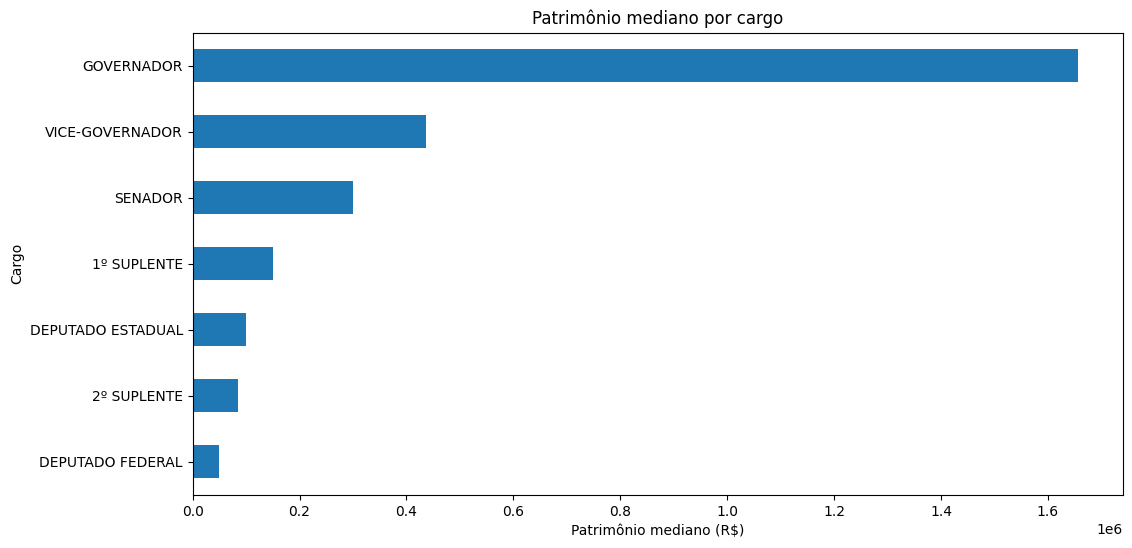

In [32]:
plt.figure(figsize=(12, 6))

patrimonio_cargo.sort_values().plot(
    kind="barh"
)

plt.title("Patrimônio mediano por cargo")
plt.xlabel("Patrimônio mediano (R$)")
plt.ylabel("Cargo")

plt.show()

2. Patrimônio por partido

In [33]:
patrimonio_partido = (
    df_final
    .groupby("SG_PARTIDO")["patrimonio_total"]
    .median()
    .sort_values(ascending=False)
)

display(patrimonio_partido.head(15))

,patrimonio_total
SG_PARTIDO,
PP,1624053.665
MDB,674338.480
PSDB,635956.260
UNIÃO,554943.250
AVANTE,552082.590
PL,342867.000
PSD,279953.195
AGIR,250000.000
PT,106572.110


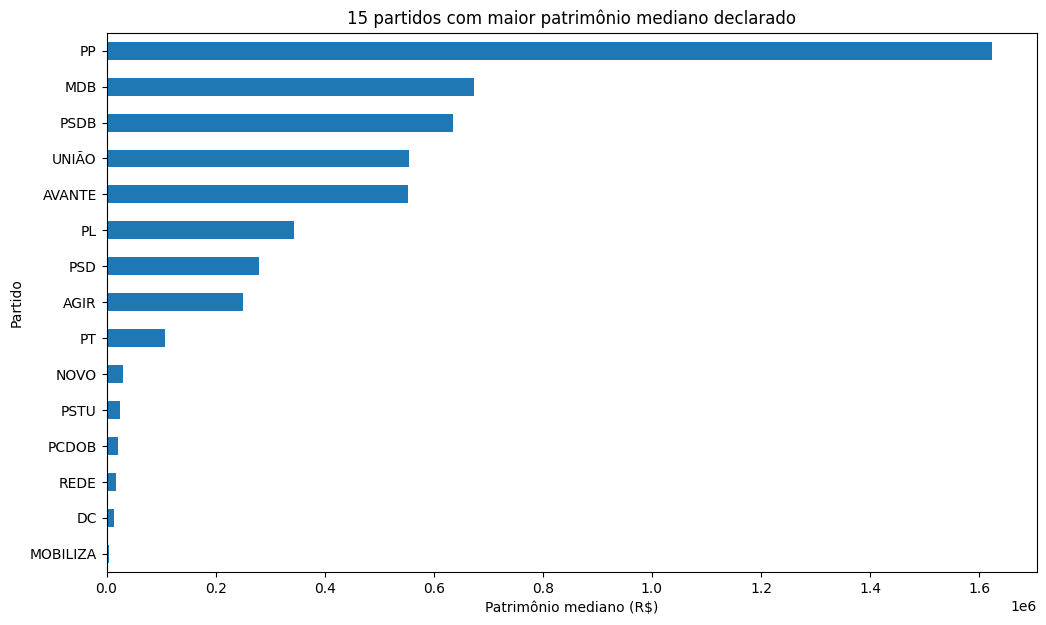

In [34]:
top_partidos = patrimonio_partido.head(15)

plt.figure(figsize=(12, 7))

top_partidos.sort_values().plot(
    kind="barh"
)

plt.title("15 partidos com maior patrimônio mediano declarado")
plt.xlabel("Patrimônio mediano (R$)")
plt.ylabel("Partido")

plt.show()

3. Distribuição por gênero

<Figure size 1000x600 with 0 Axes>

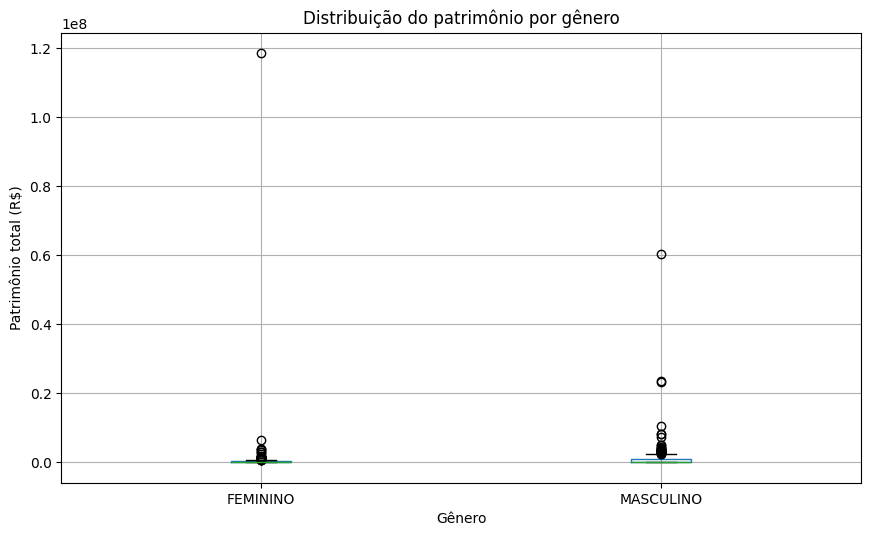

In [35]:
plt.figure(figsize=(10, 6))

df_final.boxplot(
    column="patrimonio_total",
    by="DS_GENERO",
    figsize=(10, 6)
)

plt.title("Distribuição do patrimônio por gênero")
plt.suptitle("")
plt.xlabel("Gênero")
plt.ylabel("Patrimônio total (R$)")

plt.show()

Podemos também calcular a mediana:

In [36]:
patrimonio_genero = (
    df_final
    .groupby("DS_GENERO")["patrimonio_total"]
    .agg(["count", "median", "mean"])
)

display(patrimonio_genero)

,count,median,mean
DS_GENERO,,,
FEMININO,165,5000.0,1.067512e+06
MASCULINO,304,200000.0,1.111579e+06


# A6. Narrativa — Storytelling

## Contexto

Os dados analisados apresentam as declarações de bens dos candidatos do Amazonas nas eleições de 2026. Inicialmente, os dados patrimoniais estavam separados das informações relacionadas aos candidatos. Por meio da agregação e do relacionamento pela chave `SQ_CANDIDATO`, foi possível combinar o patrimônio declarado com cargo, partido e gênero.

## Conflito / Insight

A análise demonstra que o patrimônio declarado apresenta grande variação entre os candidatos. A diferença entre média e mediana indica a influência de candidatos com valores patrimoniais elevados sobre a distribuição.

O relacionamento entre as bases também permite observar diferenças de patrimônio entre grupos de candidatos. A comparação por cargo, por exemplo, permite identificar grupos com patrimônio mediano mais elevado ou mais baixo, algo que não seria possível utilizando apenas o arquivo de bens.

## Conclusão

Os dados mostram que o patrimônio dos candidatos do Amazonas não está distribuído de maneira uniforme. A existência de valores extremos influencia significativamente as estatísticas gerais, tornando a mediana uma medida importante para a comparação entre grupos.

O JOIN com os dados dos candidatos amplia a análise ao permitir relacionar o patrimônio declarado com características como cargo, partido e gênero. Dessa forma, o conjunto de dados deixa de ser apenas uma relação de bens e passa a permitir uma análise mais ampla do perfil patrimonial das candidaturas.